# Лабораторная работа №2: Семантическая сегментация

## Цель
Освоить методы семантической сегментации изображений на примере архитектур UNet и DeepLabv3+, изучить метрики качества (IoU, Dice).

## Теория
- Классификация vs. детекция vs. сегментация.
- Архитектура UNet и её особенности.
- DeepLabv3+ и dilated convolutions.
- Метрики: IoU, Dice.

## Задания
1. Выберите модель (UNet или DeepLabv3+).
2. Возьмите датасет (Carvana, Pascal VOC или Cityscapes subset).
3. Подготовьте данные и обучите модель сегментации.
4. Оцените качество с использованием IoU и Dice.
5. Визуализируйте результаты (картинки с наложением предсказанных масок).
6. Проведите эксперимент с разными размерами входного изображения или с аугментациями.

## Вопросы
1. Почему accuracy плохо отражает качество сегментации?
2. Чем UNet отличается от "обычной" CNN?

## Требуемое содержание файла проекта
- Иллюстрации входных изображений и масок.
- Примеры предсказаний модели.
- Сравнительный анализ экспериментов.
- Ответы на контрольные вопросы.

## 1. Выбор модели: U-Net

Используется U-Net с четырьмя уровнями encoder/decoder и skip connections. Encoder извлекает признаки, decoder восстанавливает пространственное разрешение, а skip connections передают детали границ. Выход — 2 логита для каждого пикселя. Модель обучается с нуля; базовая ширина 32 канала ограничивает потребление памяти.

Реализация модели, загрузчика данных и обучения приведена в ячейках ниже.

In [31]:
import json
import random
from pathlib import Path
import numpy as np
import torch
from PIL import Image
from torch import nn
from torch.utils.data import Dataset, DataLoader

CLASS_NAMES = ["background", "car"]
IGNORE_INDEX = 255  # резерв; исходное 255 в маске превращается в класс car=1
COLORS = np.zeros((256, 3), dtype=np.uint8)
COLORS[1] = [40, 210, 120]

In [32]:
from pathlib import Path
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_ROOT = None  # либо Path к скачанной папке Carvana
OUTPUT_DIR = Path("artifacts/lab2_carvana")
IMAGE_SIZE = (256, 256)  # высота, ширина
TRAIN_LIMIT, VAL_LIMIT = None, None
BATCH_SIZE = 4
NUM_EPOCHS = 10
print("Устройство:", DEVICE)


Устройство: cuda


In [33]:
def double_conv(in_channels, out_channels):
    return nn.Sequential(nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
                         nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
                         nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
                         nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True))


class UNet(nn.Module):
    def __init__(self, num_classes=2, base=32):
        super().__init__()
        self.encoders = nn.ModuleList([double_conv(3, base), double_conv(base, base*2),
                                      double_conv(base*2, base*4), double_conv(base*4, base*8)])
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = double_conv(base*8, base*16)
        self.ups = nn.ModuleList([nn.ConvTranspose2d(base*k*2, base*k, 2, stride=2)
                                  for k in [8,4,2,1]])
        self.decoders = nn.ModuleList([double_conv(base*k*2, base*k) for k in [8,4,2,1]])
        self.head = nn.Conv2d(base, num_classes, 1)

    def forward(self, x):
        skips = []
        for encoder in self.encoders:
            x = encoder(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        for up, decoder, skip in zip(self.ups, self.decoders, reversed(skips)):
            x = up(x)
            if x.shape[-2:] != skip.shape[-2:]:
                x = nn.functional.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
            x = decoder(torch.cat([skip, x], dim=1))
        return self.head(x)  # logits: CrossEntropyLoss includes log-softmax

## 2. Датасет Carvana

Используется PNG-версия [Carvana на Kaggle](https://www.kaggle.com/datasets/ipythonx/carvana-image-masking-png). Данные скачиваются через KaggleHub в его локальный кэш.

Разделение 80/20 выполняется по идентификаторам автомобилей (часть имени перед последним номером ракурса). Все ракурсы одного автомобиля относятся только к одной выборке. По умолчанию используются все изображения; TRAIN_LIMIT и VAL_LIMIT можно задать для небольшого subset после группового разделения. Манифест сохраняется в artifacts/lab2_carvana.

Маска: 0 — фон, 1 — автомобиль. Исходные значения 255 обозначают автомобиль, а не игнорируемую область.

In [34]:
def discover_pairs(root):
    image_dirs = sorted(Path(root).rglob("train_images"))
    mask_dirs = sorted(Path(root).rglob("train_masks"))
    if len(image_dirs) != 1 or len(mask_dirs) != 1:
        raise ValueError("Ожидается одна пара папок train_images / train_masks")
    masks = {}
    for path in mask_dirs[0].iterdir():
        if path.suffix.lower() in {".png", ".gif"}:
            key = path.stem.removesuffix("_mask")
            if key in masks:
                raise ValueError(f"Повтор маски: {key}")
            masks[key] = path
    pairs = []
    for image in sorted(image_dirs[0].iterdir()):
        if image.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        if image.stem not in masks:
            raise FileNotFoundError(f"Нет маски для {image.name}")
        pairs.append((image, masks[image.stem]))
    if not pairs:
        raise ValueError("Изображения не найдены")
    return pairs

def car_id(path):
    identity, separator, angle = path.stem.rpartition("_")
    if not separator or not angle.isdigit():
        raise ValueError(f"Не удалось определить автомобиль: {path.name}")
    return identity

class CarvanaDataset(Dataset):
    def __init__(self, pairs, size=(256,256), augment=False):
        self.pairs, self.size, self.augment = list(pairs), tuple(size), augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        image_path, mask_path = self.pairs[index]
        h, w = self.size
        with Image.open(image_path) as im:
            original_size = im.size
            image = np.array(im.convert("RGB").resize((w,h), Image.Resampling.BILINEAR))
        with Image.open(mask_path) as im:
            if im.size != original_size:
                raise ValueError(f"Размеры изображения и маски различаются: {image_path}")
            # convert L раскрывает палитру GIF/PNG; только бинарные значения.
            mask = np.array(im.convert("L").resize((w,h), Image.Resampling.NEAREST))
        if not np.isin(mask, [0,1,255]).all():
            raise ValueError(f"Маска не бинарная: {mask_path}")
        mask = (mask > 0).astype(np.int64)
        if self.augment and torch.rand(()).item() < .5:
            image, mask = image[:, ::-1], mask[:, ::-1]
        return (torch.from_numpy(image.copy()).permute(2,0,1).float()/255,
                torch.from_numpy(mask.copy()).long())

def make_loaders(root, output, train_limit=None, val_limit=None,
                 size=(256,256), batch_size=4, seed=42):
    pairs = discover_pairs(root)
    groups = sorted({car_id(image) for image, _ in pairs})
    if len(groups) < 2:
        raise ValueError("Нужно минимум два автомобиля")
    rng = random.Random(seed)
    rng.shuffle(groups)
    val_groups = set(groups[:max(1, round(len(groups)*.2))])
    train_pairs = [p for p in pairs if car_id(p[0]) not in val_groups]
    val_pairs = [p for p in pairs if car_id(p[0]) in val_groups]
    rng.shuffle(train_pairs)
    rng.shuffle(val_pairs)
    if any(limit is not None and limit < 1 for limit in (train_limit, val_limit)):
        raise ValueError("Ограничения должны быть положительными или None")
    train_pairs, val_pairs = train_pairs[:train_limit], val_pairs[:val_limit]
    assert not ({car_id(p[0]) for p in train_pairs} & {car_id(p[0]) for p in val_pairs})
    output = Path(output)
    output.mkdir(parents=True, exist_ok=True)
    manifest = {name: [[str(p.relative_to(root)) for p in pair] for pair in subset]
                for name, subset in [("train", train_pairs), ("val", val_pairs)]}
    manifest.update(dataset="ipythonx/carvana-image-masking-png", seed=seed,
                    split_strategy="car_id_80_20")
    (output/"subset_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
    train = CarvanaDataset(train_pairs, size, augment=True)
    val = CarvanaDataset(val_pairs, size)
    common = dict(batch_size=batch_size, num_workers=0, pin_memory=torch.cuda.is_available())
    return (DataLoader(train, shuffle=True, generator=torch.Generator().manual_seed(seed), **common),
            DataLoader(val, shuffle=False, **common))

In [35]:
if DATA_ROOT is None:
    try:
        import kagglehub
    except ImportError as exc:
        raise ImportError("Установите зависимость отдельной ячейкой: %pip install kagglehub") from exc
    DATA_ROOT = Path(kagglehub.dataset_download("ipythonx/carvana-image-masking-png"))
train_loader, val_loader = make_loaders(
    DATA_ROOT, OUTPUT_DIR, TRAIN_LIMIT, VAL_LIMIT, IMAGE_SIZE, BATCH_SIZE, seed=SEED)
print("Данные:", DATA_ROOT)
print("Train:", len(train_loader.dataset), "Validation:", len(val_loader.dataset))
print(dict(enumerate(CLASS_NAMES)))

Данные: C:\Users\propc\.cache\kagglehub\datasets\ipythonx\carvana-image-masking-png\versions\1
Train: 4064 Validation: 1024
{0: 'background', 1: 'car'}


## 3. Подготовка данных и обучение

Изображения приводятся к RGB, размеру 256×256 и диапазону [0, 1]. Маски изменяют размер методом nearest neighbour. Для train применяется случайное горизонтальное отражение пары изображение–маска, validation не аугментируется. Ниже показаны реальные входные изображения и цветная разметка (чёрный — фон, зелёный — автомобиль).

Обучение: CrossEntropyLoss с ignore_index=255, AdamW, mixed precision на CUDA, снижение learning rate при остановке улучшения validation loss. Лучшая модель сохраняется по минимальной validation loss. Метрики IoU/Dice и эксперименты относятся к следующим заданиям.

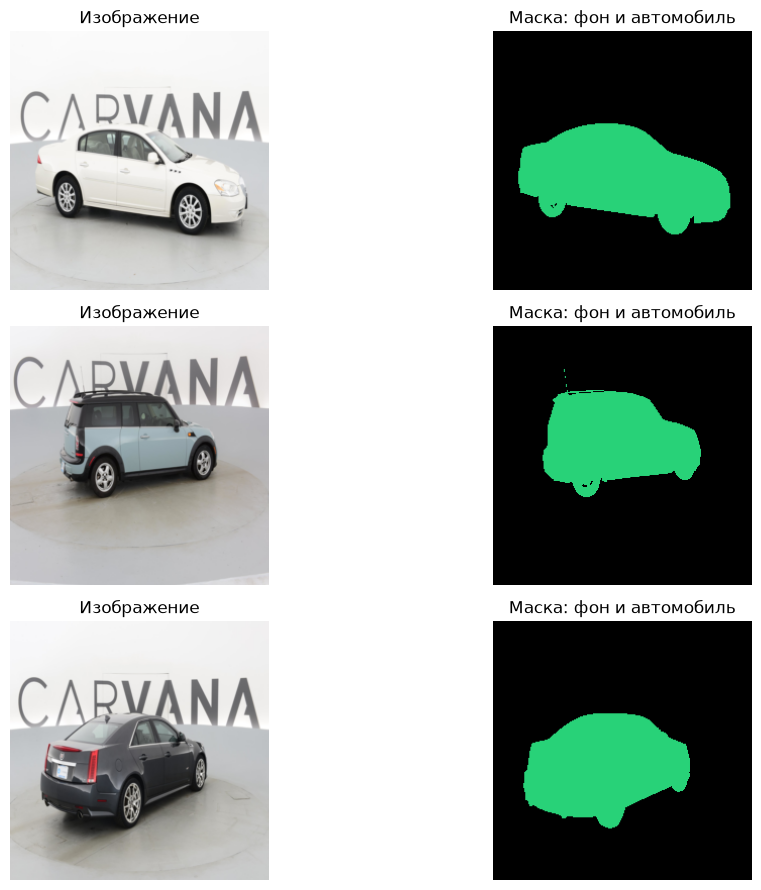

In [36]:
preview = CarvanaDataset(train_loader.dataset.pairs, IMAGE_SIZE)
fig, axes = plt.subplots(3, 2, figsize=(12, 9), squeeze=False)
for row in range(min(3, len(preview))):
    image, mask = preview[row]
    colored = COLORS[mask.numpy()]
    axes[row, 0].imshow(image.permute(1, 2, 0))
    axes[row, 1].imshow(colored)
for row in axes:
    row[0].set_title("Изображение")
    row[1].set_title("Маска: фон и автомобиль")
    for ax in row:
        ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "data_preview.png", dpi=150)
plt.show()


In [37]:
import time
from tqdm import tqdm

def epoch_scores(confusion):
    matrix = confusion.double()
    tp = matrix.diag()
    actual, predicted = matrix.sum(1), matrix.sum(0)
    union, denominator = actual + predicted - tp, actual + predicted
    iou = torch.where(union > 0, tp / union, torch.nan)
    dice = torch.where(denominator > 0, 2 * tp / denominator, torch.nan)
    return dict(mean_iou=float(iou.nanmean()), mean_dice=float(dice.nanmean()),
                pixel_accuracy=float(tp.sum() / matrix.sum()),
                car_iou=float(iou[1]), car_dice=float(dice[1]))

def run_epoch(model, loader, device, optimizer=None, scaler=None, description="Проверка"):
    training = optimizer is not None
    model.train(training)
    total_loss, total_pixels = 0., 0
    confusion = torch.zeros((len(CLASS_NAMES), len(CLASS_NAMES)),
                            dtype=torch.int64, device=device)
    with tqdm(loader, desc=description, unit="батч", leave=training,
              dynamic_ncols=True, colour="#26a69a" if training else "#64b5f6") as progress:
        for images, masks in progress:
            images, masks = images.to(device), masks.to(device)
            valid = masks != IGNORE_INDEX
            pixels = int(valid.sum())
            if not pixels:
                continue
            if training:
                optimizer.zero_grad(set_to_none=True)
            with torch.set_grad_enabled(training):
                with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
                    logits = model(images)
                    loss = nn.functional.cross_entropy(logits, masks, ignore_index=IGNORE_INDEX)
                if not torch.isfinite(loss):
                    raise RuntimeError("Non-finite loss")
                if training:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), 1.)
                    scaler.step(optimizer)
                    scaler.update()
            # Метрики по общей матрице ошибок эпохи, без графа градиентов
            with torch.no_grad():
                predicted = logits.detach().argmax(1)
                count = len(CLASS_NAMES)
                ids = count * masks[valid] + predicted[valid]
                confusion += torch.bincount(ids, minlength=count**2).reshape(count, count)
            total_loss += loss.item() * pixels
            total_pixels += pixels
            progress.set_postfix(loss=f"{loss.item():.4f}",
                                 avg=f"{total_loss / total_pixels:.4f}")
    if not total_pixels:
        raise ValueError("No valid pixels in this split")
    return total_loss / total_pixels, epoch_scores(confusion)

def fit(model, train_loader, val_loader, device, output, epochs=20, lr=1e-3):
    if epochs < 1:
        raise ValueError("epochs должно быть положительным")
    output = Path(output)
    output.mkdir(parents=True, exist_ok=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=.5)
    scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")
    history, best, best_record = [], float("inf"), None
    print(f"U-Net · {len(train_loader.dataset)} train / {len(val_loader.dataset)} val · "
          f"{epochs} эпох · {device}")
    for epoch in range(1, epochs+1):
        started = time.perf_counter()
        current_lr = optimizer.param_groups[0]["lr"]
        train_loss, train_scores = run_epoch(
            model, train_loader, device, optimizer, scaler,
            description=f"Обучение {epoch:02d}/{epochs:02d}")
        val_loss, val_scores = run_epoch(model, val_loader, device,
                                        description="Валидация")
        record = dict(epoch=epoch, train_loss=train_loss, val_loss=val_loss,
                      lr=current_lr, seconds=time.perf_counter()-started,
                      **{f"train_{k}": v for k, v in train_scores.items()},
                      **{f"val_{k}": v for k, v in val_scores.items()})
        history.append(record)
        scheduler.step(val_loss)
        improved = val_loss < best
        if improved:
            best, best_record = val_loss, record.copy()
            torch.save(dict(model_state_dict=model.state_dict(), epoch=epoch, val_loss=best,
                            classes=CLASS_NAMES, size=train_loader.dataset.size,
                            optimizer_state_dict=optimizer.state_dict(),
                            scheduler_state_dict=scheduler.state_dict(),
                            scaler_state_dict=scaler.state_dict(), history=history,
                            validation_metrics=val_scores),
                       output / "unet_best.pth")
        (output / "history.json").write_text(json.dumps(history, indent=2), encoding="utf-8")
        marker = " | лучший checkpoint сохранён" if improved else ""
        tqdm.write(
            f"Итог {epoch:02d}/{epochs:02d} · loss {train_loss:.4f} → val {val_loss:.4f}\n"
            f"  val: mIoU {val_scores['mean_iou']:.4f} | Dice {val_scores['mean_dice']:.4f} | "
            f"pixel acc {val_scores['pixel_accuracy']:.4f} | IoU car {val_scores['car_iou']:.4f}\n"
            f"  lr {current_lr:.2g} | {record['seconds']:.1f} с{marker}"
        )
    print(
        f"\nЛучший результат по validation loss · эпоха {best_record['epoch']}\n"
        f"loss={best:.4f} | mIoU={best_record['val_mean_iou']:.4f} | "
        f"Dice={best_record['val_mean_dice']:.4f} | "
        f"pixel acc={best_record['val_pixel_accuracy']:.4f}\n"
        f"Модель сохранена: {output / 'unet_best.pth'}"
    )
    return history


In [38]:
model = UNet(num_classes=len(CLASS_NAMES), base=32).to(DEVICE)
print("Параметров:", sum(p.numel() for p in model.parameters()))
history = fit(model, train_loader, val_loader, DEVICE, OUTPUT_DIR, epochs=NUM_EPOCHS, lr=1e-3)


Параметров: 7763074
U-Net · 4064 train / 1024 val · 10 эпох · cuda


Обучение 01/10: 100%|██████████| 1016/1016 [02:09<00:00,  7.85батч/s, avg=0.0434, loss=0.0123]


Итог 01/10 · loss 0.0434 → val 0.0322
  val: mIoU 0.9643 | Dice 0.9817 | pixel acc 0.9877 | IoU car 0.9441
  lr 0.001 | 159.5 с | лучший checkpoint сохранён


Обучение 02/10: 100%|██████████| 1016/1016 [02:08<00:00,  7.88батч/s, avg=0.0140, loss=0.0186]


Итог 02/10 · loss 0.0140 → val 0.0122
  val: mIoU 0.9862 | Dice 0.9930 | pixel acc 0.9954 | IoU car 0.9781
  lr 0.001 | 159.2 с | лучший checkpoint сохранён


...

Итог 08/10 · loss 0.0074 → val 0.0082
  val: mIoU 0.9907 | Dice 0.9953 | pixel acc 0.9969 | IoU car 0.9853
  lr 0.001 | 158.4 с | лучший checkpoint сохранён


Обучение 09/10: 100%|██████████| 1016/1016 [02:10<00:00,  7.80батч/s, avg=0.0068, loss=0.0088]


Итог 09/10 · loss 0.0068 → val 0.0096
  val: mIoU 0.9894 | Dice 0.9946 | pixel acc 0.9965 | IoU car 0.9832
  lr 0.001 | 160.5 с


Обучение 10/10: 100%|██████████| 1016/1016 [02:09<00:00,  7.82батч/s, avg=0.0091, loss=0.0061]
                                                                                       vg=0.0083, loss=0.0076]

Итог 10/10 · loss 0.0091 → val 0.0083
  val: mIoU 0.9908 | Dice 0.9954 | pixel acc 0.9969 | IoU car 0.9854
  lr 0.001 | 161.0 с

Лучший результат по validation loss · эпоха 8
loss=0.0082 | mIoU=0.9907 | Dice=0.9953 | pixel acc=0.9969
Модель сохранена: artifacts\lab2_carvana\unet_best.pth


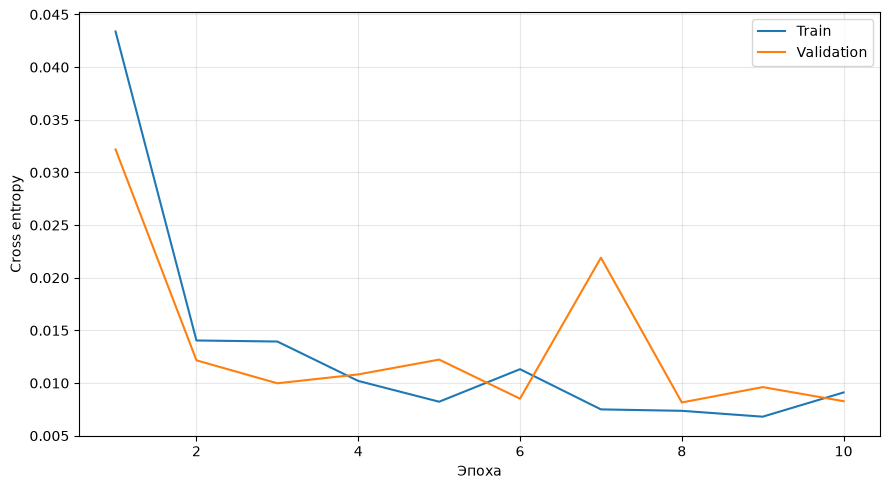

Лучшая эпоха: 8 Validation loss: 0.008155799694577581


In [39]:
import json
history = json.loads((OUTPUT_DIR / "history.json").read_text(encoding="utf-8"))
plt.figure(figsize=(9, 5))
plt.plot([r["epoch"] for r in history], [r["train_loss"] for r in history], label="Train")
plt.plot([r["epoch"] for r in history], [r["val_loss"] for r in history], label="Validation")
plt.xlabel("Эпоха")
plt.ylabel("Cross entropy")
plt.legend()
plt.grid(alpha=.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss.png", dpi=150)
plt.show()
best = min(history, key=lambda r: r["val_loss"])
print("Лучшая эпоха:", best["epoch"], "Validation loss:", best["val_loss"])


## 4. Оценка качества: IoU и Dice

Загружается лучший checkpoint. Оценка выполняется на сохранённом validation subset без аугментаций, при размере входа из checkpoint. Это та же выборка, по которой выбиралась модель, а не независимый тест.

Матрица ошибок накапливается по всем изображениям (строки — истинный класс, столбцы — предсказанный). IoU = TP/(TP+FP+FN), Dice = 2TP/(2TP+FP+FN). В Carvana оцениваются все пиксели; исходная метка 255 преобразована в класс автомобиля 1. Средние рассчитываются по классам с ненулевым знаменателем; полностью отсутствующие классы обозначаются «—». Отдельно показываются средние с фоном и без него.

| Метрика | Значение |
|---|---:|
| mean_IoU | 0.9907 |
| mean_Dice | 0.9953 |
| mean_IoU_without_background | 0.9853 |
| mean_Dice_without_background | 0.9926 |

| Класс | IoU | Dice | Пикселей GT |
|---|---:|---:|---:|
| background | 0.9961 | 0.9981 | 53105937 |
| car | 0.9853 | 0.9926 | 14002927 |

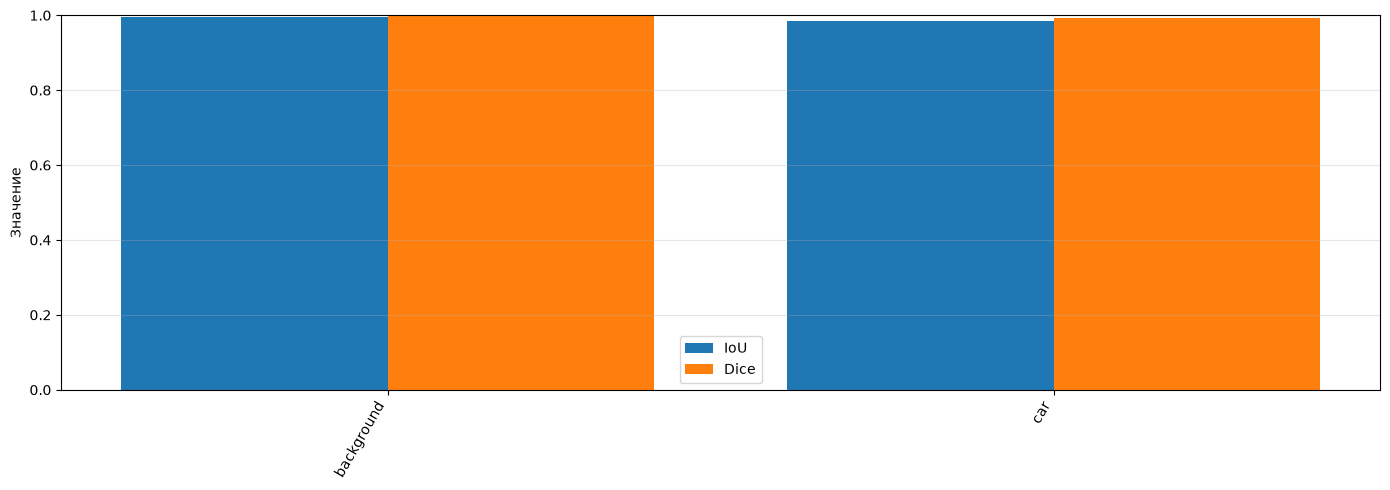

Checkpoint epoch: 8


In [40]:
from IPython.display import Markdown, display

checkpoint = torch.load(OUTPUT_DIR / "unet_best.pth", map_location="cpu", weights_only=True)
if checkpoint["classes"] != CLASS_NAMES:
    raise ValueError("Классы checkpoint не совпадают с Carvana")
eval_model = UNet(num_classes=len(CLASS_NAMES), base=32)
eval_model.load_state_dict(checkpoint["model_state_dict"])
eval_model = eval_model.to(DEVICE).eval()

# Восстанавливаем именно сохранённый subset, независимо от текущего seed/limit
manifest = json.loads((OUTPUT_DIR / "subset_manifest.json").read_text(encoding="utf-8"))
eval_dataset = CarvanaDataset([], tuple(checkpoint["size"]))
eval_dataset.pairs = [(DATA_ROOT / image, DATA_ROOT / mask) for image, mask in manifest["val"]]
if not eval_dataset.pairs:
    raise ValueError("Пустой validation subset")
eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

def scores_from_confusion(confusion):
    matrix = confusion.to(torch.float64)
    tp = matrix.diag()
    actual, predicted = matrix.sum(1), matrix.sum(0)
    union = actual + predicted - tp
    denominator = actual + predicted
    nan = torch.full_like(tp, float("nan"))
    iou = torch.where(union > 0, tp / union, nan)
    dice = torch.where(denominator > 0, 2 * tp / denominator, nan)
    return iou, dice, actual

@torch.inference_mode()
def evaluate_segmentation(model, loader):
    count = len(CLASS_NAMES)
    confusion = torch.zeros((count, count), dtype=torch.int64, device=DEVICE)
    model.eval()
    for images, masks in loader:
        masks = masks.to(DEVICE)
        predicted = model(images.to(DEVICE)).argmax(dim=1)
        valid = masks != IGNORE_INDEX
        ids = count * masks[valid] + predicted[valid]
        confusion += torch.bincount(ids, minlength=count * count).reshape(count, count)
    return confusion.cpu()

confusion = evaluate_segmentation(eval_model, eval_loader)
iou, dice, support = scores_from_confusion(confusion)
summary = {
    "mean_IoU": float(iou.nanmean()),
    "mean_Dice": float(dice.nanmean()),
    "mean_IoU_without_background": float(iou[1:].nanmean()),
    "mean_Dice_without_background": float(dice[1:].nanmean()),
}
def formatted(value):
    return f"{value:.4f}" if np.isfinite(value) else "—"

display(Markdown("| Метрика | Значение |\n|---|---:|\n" +
    "\n".join(f"| {name} | {formatted(value)} |" for name, value in summary.items())))
display(Markdown("| Класс | IoU | Dice | Пикселей GT |\n|---|---:|---:|---:|\n" +
    "\n".join(f"| {name} | {formatted(float(iou[k]))} | {formatted(float(dice[k]))} | {int(support[k])} |"
              for k, name in enumerate(CLASS_NAMES))))
def nullable(value):
    return float(value) if np.isfinite(float(value)) else None

results = {
    "split": "validation", "images": len(eval_dataset),
    "checkpoint_epoch": checkpoint["epoch"], "image_size": list(checkpoint["size"]),
    "summary": {k: nullable(v) for k, v in summary.items()},
    "per_class": [{"class": name, "IoU": nullable(iou[k]), "Dice": nullable(dice[k]),
                   "gt_pixels": int(support[k])} for k, name in enumerate(CLASS_NAMES)],
}
(OUTPUT_DIR / "segmentation_metrics.json").write_text(
    json.dumps(results, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")
np.save(OUTPUT_DIR / "confusion_matrix.npy", confusion.numpy())

x = np.arange(len(CLASS_NAMES))
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - .2, iou.numpy(), .4, label="IoU")
ax.bar(x + .2, dice.numpy(), .4, label="Dice")
ax.set_xticks(x, CLASS_NAMES, rotation=60, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Значение")
ax.legend()
ax.grid(axis="y", alpha=.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "iou_dice.png", dpi=150)
plt.show()
print("Checkpoint epoch:", checkpoint["epoch"])


## 5. Визуализация предсказаний

Первые пять изображений сохранённого validation subset показываются без отбора по качеству. Для каждого выводятся исходное изображение, эталонная маска, предсказание и наложение предсказанных объектов на изображение. Фон при наложении прозрачен. Цвета классов приведены в легенде.

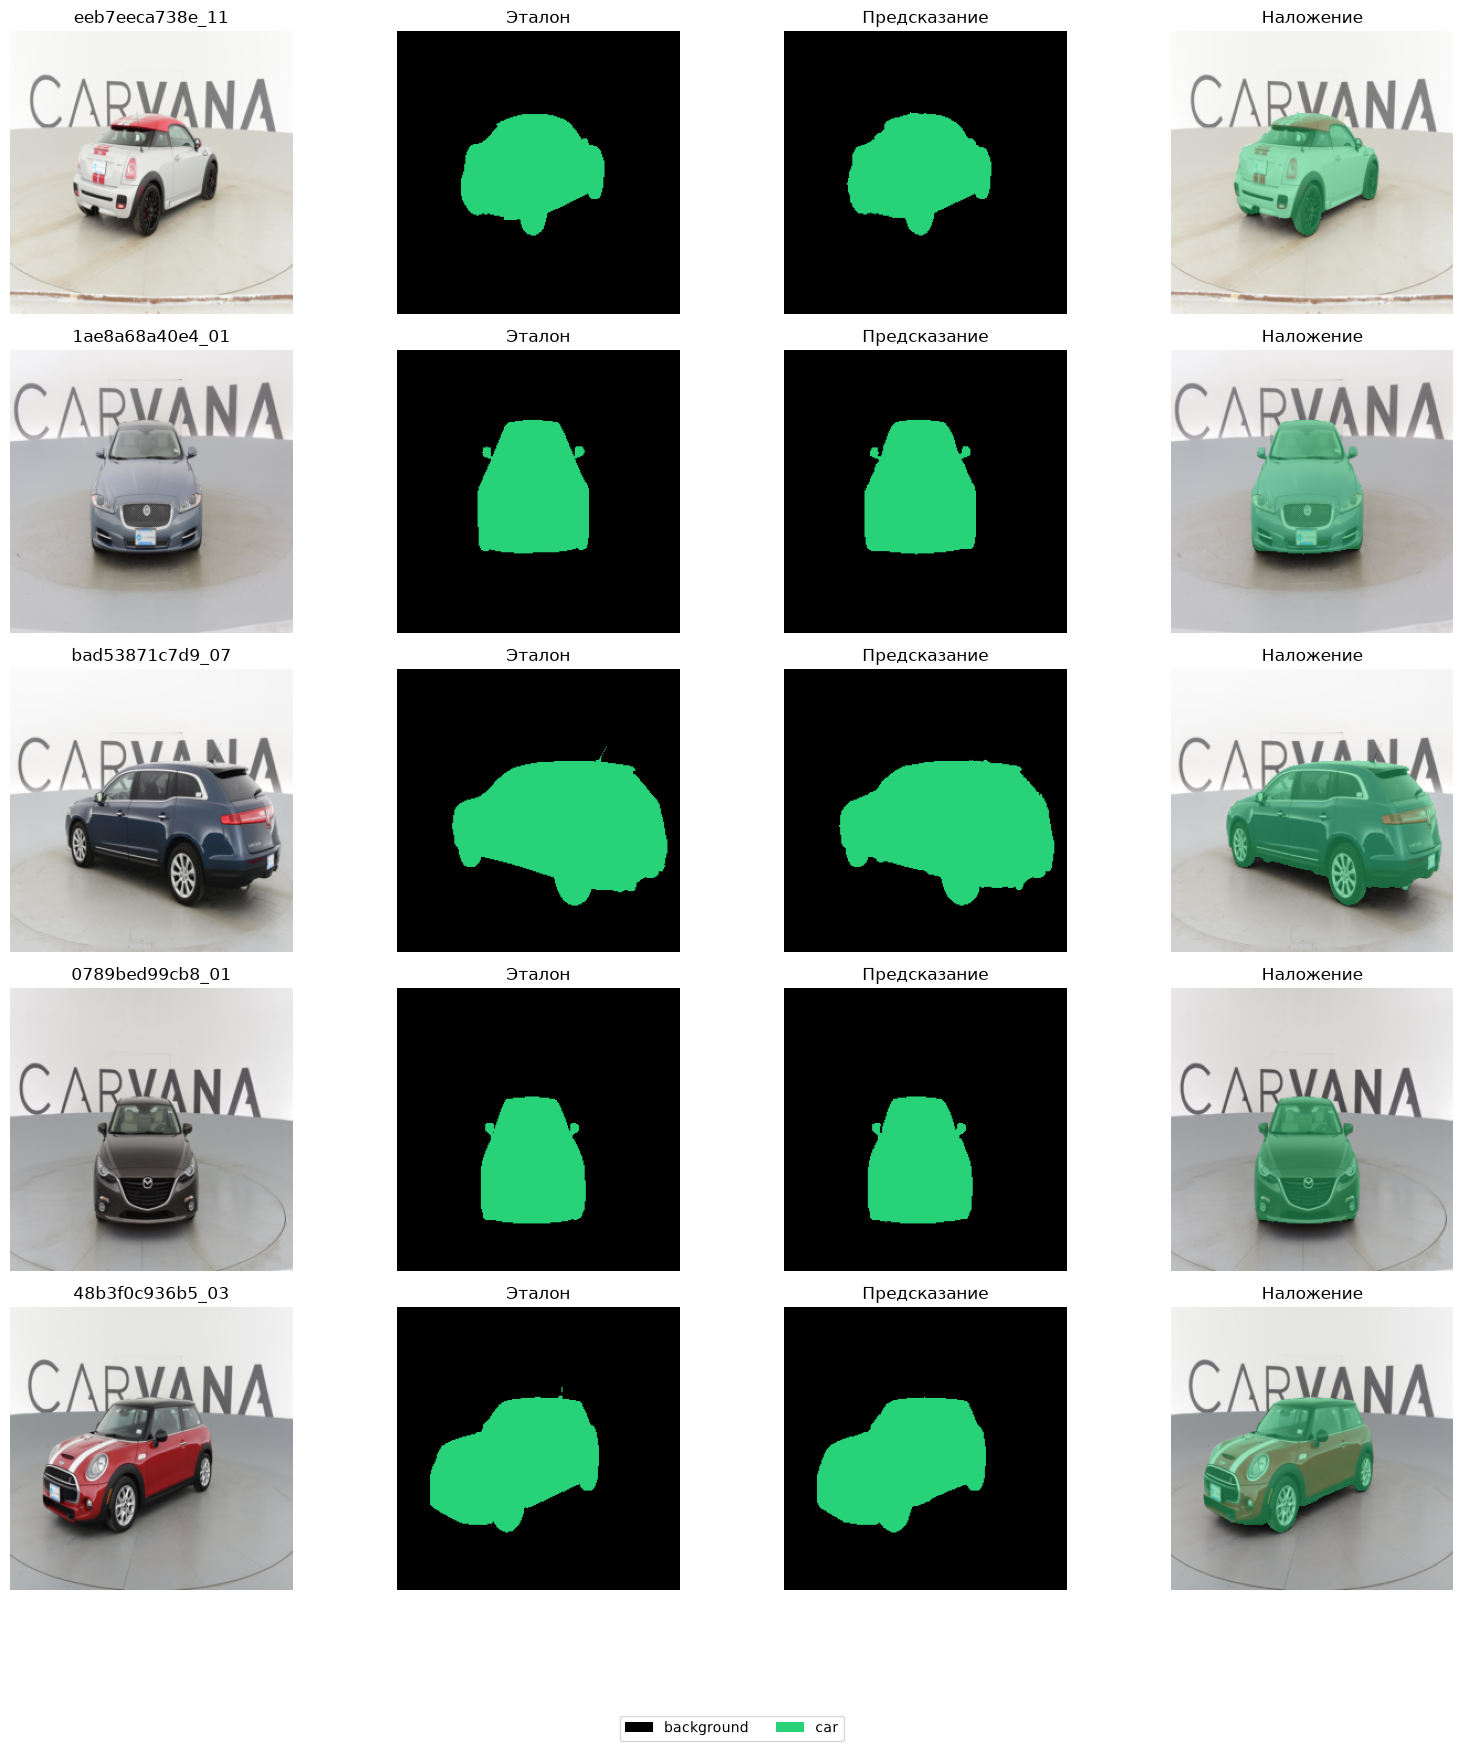

In [41]:
from matplotlib.patches import Patch

indices = list(range(min(5, len(eval_dataset))))
fig, axes = plt.subplots(len(indices), 4, figsize=(16, 3.5 * len(indices)), squeeze=False)
shown_classes = set()
with torch.inference_mode():
    for row, index in enumerate(indices):
        image, target = eval_dataset[index]
        pred = eval_model(image.unsqueeze(0).to(DEVICE)).argmax(1)[0].cpu().numpy()
        rgb = image.permute(1, 2, 0).numpy()
        target = target.numpy()
        overlay = rgb.copy()
        objects = pred != 0
        overlay[objects] = .55 * rgb[objects] + .45 * COLORS[pred[objects]] / 255.
        shown_classes.update(int(k) for k in np.unique(target) if k != IGNORE_INDEX)
        shown_classes.update(int(k) for k in np.unique(pred))
        panels = [rgb, COLORS[target], COLORS[pred], overlay]
        titles = ["Изображение", "Эталон", "Предсказание", "Наложение"]
        for ax, panel, title in zip(axes[row], panels, titles):
            ax.imshow(panel)
            ax.set_title(title)
            ax.axis("off")
        axes[row, 0].set_title(eval_dataset.pairs[index][0].stem)
handles = [Patch(facecolor=COLORS[k] / 255., label=CLASS_NAMES[k]) for k in sorted(shown_classes)]

fig.legend(handles=handles, loc="lower center", ncol=6)
fig.tight_layout(rect=(0, .08, 1, 1))
fig.savefig(OUTPUT_DIR / "segmentation_predictions.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Эксперимент: влияние разрешения изображения

Сравниваются U-Net при входе 128×128 и 256×256. По умолчанию 256×256 загружается из основного checkpoint, а 128×128 обучается заново. Для повторного обучения обеих конфигураций установите REUSE_256_CHECKPOINT=False. В этом режиме совпадают начальные веса, выборки и бюджет эпох. При загрузке старой модели условия и число эпох могут отличаться: разницу качества нельзя объяснить исключительно разрешением. Неизвестное время старого обучения обозначается «—». Результаты основного обучения не заменяются.

Лучший checkpoint каждой конфигурации выбирается по минимальной validation loss. IoU/Dice считаются по общей матрице ошибок. Для итогового сравнения предсказания обеих моделей приводятся к общей сетке 256×256: логиты интерполируются bilinear, эталонные маски — nearest neighbour. Это уменьшает влияние разного разрешения самих масок на сравнение. Validation участвует в выборе checkpoint, поэтому результаты не являются независимой тестовой оценкой.

In [42]:
import copy
import time
import gc
from torch.nn import functional as F

REUSE_256_CHECKPOINT = False  # переиспользовать уже обученный 256×256
EXPERIMENT_EPOCHS = 10
EXPERIMENT_SIZES = [(128, 128), (256, 256)]
REFERENCE_SIZE = (256, 256)
EXPERIMENT_ROOT = OUTPUT_DIR / "resolution_experiment"
EXPERIMENT_ROOT.mkdir(parents=True, exist_ok=True)

# Используем зафиксированное разделение по автомобилям
experiment_manifest = json.loads((OUTPUT_DIR / "subset_manifest.json").read_text(encoding="utf-8"))
experiment_pairs = {
    split: [(DATA_ROOT / image, DATA_ROOT / mask) for image, mask in experiment_manifest[split]]
    for split in ("train", "val")
}
assert not ({car_id(p[0]) for p in experiment_pairs["train"]} &
            {car_id(p[0]) for p in experiment_pairs["val"]})

def reset_experiment_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

@torch.inference_mode()
def resolution_metrics(network, pairs, input_size):
    # Изображения сначала уменьшаются к входному размеру, GT остаётся на общей сетке.
    reference = CarvanaDataset(pairs, REFERENCE_SIZE, augment=False)
    loader = DataLoader(reference, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    confusion = torch.zeros((2, 2), dtype=torch.int64, device=DEVICE)
    network.eval()
    for images, targets in loader:
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        images = F.interpolate(images, size=input_size, mode="bilinear",
                               align_corners=False, antialias=True)
        logits = network(images)
        logits = F.interpolate(logits, size=REFERENCE_SIZE, mode="bilinear", align_corners=False)
        predictions = logits.argmax(1)
        confusion += torch.bincount((2 * targets + predictions).flatten(),
                                    minlength=4).reshape(2, 2)
    matrix = confusion.double()
    tp = matrix.diag()
    actual, predicted = matrix.sum(1), matrix.sum(0)
    union, denominator = actual + predicted - tp, actual + predicted
    iou = torch.where(union > 0, tp / union, torch.nan)
    dice = torch.where(denominator > 0, 2 * tp / denominator, torch.nan)
    return dict(mean_IoU=float(iou.nanmean()), mean_Dice=float(dice.nanmean()),
                car_IoU=float(iou[1]), car_Dice=float(dice[1]))

reset_experiment_seed()
initial_weights = copy.deepcopy(UNet(num_classes=2, base=32).state_dict())


In [43]:
# Проверяем существующий checkpoint до начала обучения 128×128
reused_checkpoint = None
if REUSE_256_CHECKPOINT:
    reused_checkpoint = torch.load(OUTPUT_DIR / "unet_best.pth", map_location="cpu", weights_only=True)
    if tuple(reused_checkpoint["size"]) != (256, 256) or reused_checkpoint["classes"] != CLASS_NAMES:
        raise ValueError("Нужен checkpoint Carvana 256×256; выберите повторное обучение")
    old_history = json.loads((OUTPUT_DIR / "history.json").read_text(encoding="utf-8"))

experiment_results = []
for size in EXPERIMENT_SIZES:
    reset_experiment_seed()
    reuse = REUSE_256_CHECKPOINT and size == (256, 256)
    run_dir = EXPERIMENT_ROOT / f"{size[0]}x{size[1]}"
    run_dir.mkdir(parents=True, exist_ok=True)
    (run_dir / "subset_manifest.json").write_text(
        json.dumps(experiment_manifest, indent=2), encoding="utf-8")
    network = UNet(num_classes=2, base=32).to(DEVICE)
    if reuse:
        saved = reused_checkpoint
        run_history = old_history
        seconds = None  # время старого запуска не измерялось
        print("256×256: загрузка основного checkpoint без обучения")
    else:
        network.load_state_dict(initial_weights)
        train_data = CarvanaDataset(experiment_pairs["train"], size, augment=True)
        valid_data = CarvanaDataset(experiment_pairs["val"], size, augment=False)
        exp_train = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
                               generator=torch.Generator().manual_seed(SEED))
        exp_valid = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
        print(f"Обучение {size[0]}×{size[1]}: {EXPERIMENT_EPOCHS} эпох")
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        started = time.perf_counter()
        run_history = fit(network, exp_train, exp_valid, DEVICE, run_dir,
                          epochs=EXPERIMENT_EPOCHS, lr=1e-3)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        seconds = time.perf_counter() - started
        saved = torch.load(run_dir / "unet_best.pth", map_location="cpu", weights_only=True)
    network.load_state_dict(saved["model_state_dict"])
    metrics = resolution_metrics(network, experiment_pairs["val"], size)
    # Отдельная история сравнения не заменяет историю checkpoint в папке запуска.
    (run_dir / "comparison_history.json").write_text(json.dumps(run_history, indent=2), encoding="utf-8")
    result = dict(size=list(size), epochs=len(run_history), best_epoch=saved["epoch"],
                  source="loaded" if reuse else "trained",
                  checkpoint_path=str((OUTPUT_DIR if reuse else run_dir) / "unet_best.pth"),
                  validation_loss=saved["val_loss"], training_seconds=seconds, **metrics)
    experiment_results.append(result)
    (run_dir / "metrics.json").write_text(json.dumps(result, indent=2), encoding="utf-8")
    (EXPERIMENT_ROOT / "comparison.json").write_text(
        json.dumps(experiment_results, indent=2), encoding="utf-8")
    print(f"Автомобиль: IoU={metrics['car_IoU']:.4f}, Dice={metrics['car_Dice']:.4f}")
    del network, saved
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


Обучение 128×128: 10 эпох
U-Net · 4064 train / 1024 val · 10 эпох · cuda


Обучение 01/10: 100%|██████████| 1016/1016 [01:58<00:00,  8.60батч/s, avg=0.0441, loss=0.0150]


Итог 01/10 · loss 0.0441 → val 0.0195
  val: mIoU 0.9779 | Dice 0.9888 | pixel acc 0.9926 | IoU car 0.9651
  lr 0.001 | 144.2 с | лучший checkpoint сохранён


Обучение 02/10: 100%|██████████| 1016/1016 [01:58<00:00,  8.58батч/s, avg=0.0158, loss=0.0128]


Итог 02/10 · loss 0.0158 → val 0.0126
  val: mIoU 0.9854 | Dice 0.9926 | pixel acc 0.9951 | IoU car 0.9769
  lr 0.001 | 144.4 с | лучший checkpoint сохранён


...

Итог 08/10 · loss 0.0074 → val 0.0082
  val: mIoU 0.9907 | Dice 0.9953 | pixel acc 0.9969 | IoU car 0.9853
  lr 0.001 | 166.3 с | лучший checkpoint сохранён


Обучение 09/10: 100%|██████████| 1016/1016 [02:15<00:00,  7.50батч/s, avg=0.0068, loss=0.0088]


Итог 09/10 · loss 0.0068 → val 0.0096
  val: mIoU 0.9894 | Dice 0.9946 | pixel acc 0.9965 | IoU car 0.9832
  lr 0.001 | 166.7 с


Обучение 10/10: 100%|██████████| 1016/1016 [02:24<00:00,  7.01батч/s, avg=0.0091, loss=0.0061]


Итог 10/10 · loss 0.0091 → val 0.0083
  val: mIoU 0.9908 | Dice 0.9954 | pixel acc 0.9969 | IoU car 0.9854
  lr 0.001 | 182.2 с

Лучший результат по validation loss · эпоха 8
loss=0.0082 | mIoU=0.9907 | Dice=0.9953 | pixel acc=0.9969
Модель сохранена: artifacts\lab2_carvana\resolution_experiment\256x256\unet_best.pth
Автомобиль: IoU=0.9853, Dice=0.9926


| Вход | Режим | Эпох | Лучшая эпоха | mIoU | mDice | IoU car | Dice car | Время, мин |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| 128×128 | trained | 10 | 10 | 0.9885 | 0.9942 | 0.9819 | 0.9909 | 24.2 |
| 256×256 | trained | 10 | 8 | 0.9907 | 0.9953 | 0.9853 | 0.9926 | 27.9 |

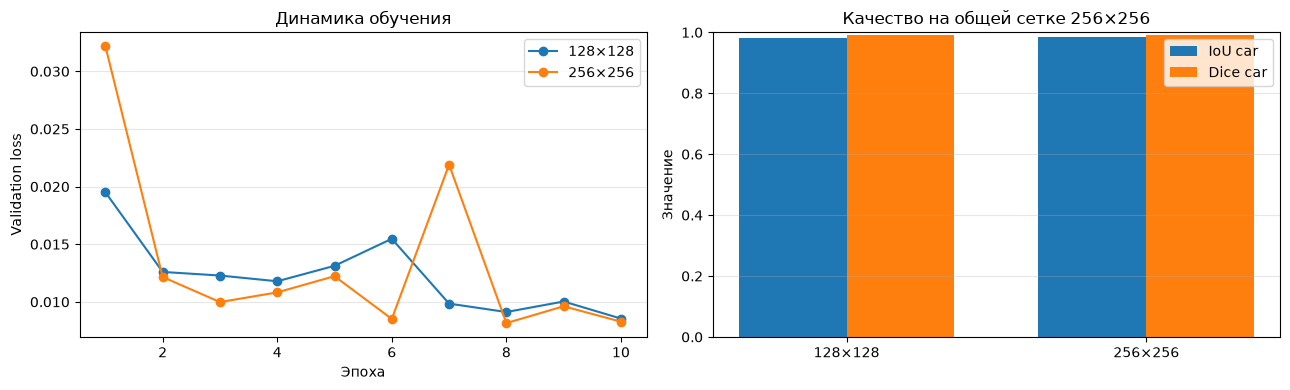

При переходе с 128×128 на 256×256 IoU автомобиля изменился на **+0.0034**. Обучение заняло **24.2** и **27.9 мин** соответственно. 

In [44]:
from IPython.display import Markdown, display

experiment_results = json.loads((EXPERIMENT_ROOT / "comparison.json").read_text(encoding="utf-8"))
if len(experiment_results) != len(EXPERIMENT_SIZES):
    raise RuntimeError("Дождитесь завершения обеих конфигураций")
def training_time(result):
    seconds = result["training_seconds"]
    return "—" if seconds is None else f"{seconds / 60:.1f}"

rows = ["| Вход | Режим | Эпох | Лучшая эпоха | mIoU | mDice | IoU car | Dice car | Время, мин |",
        "|---|---|---:|---:|---:|---:|---:|---:|---:|"]
for r in experiment_results:
    rows.append(f"| {r['size'][0]}×{r['size'][1]} | {r.get('source', 'trained')} | {r['epochs']} | {r['best_epoch']} | "
                f"{r['mean_IoU']:.4f} | {r['mean_Dice']:.4f} | "
                f"{r['car_IoU']:.4f} | {r['car_Dice']:.4f} | {training_time(r)} |")
display(Markdown("\n".join(rows)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for r in experiment_results:
    label = f"{r['size'][0]}×{r['size'][1]}"
    folder = EXPERIMENT_ROOT / f"{r['size'][0]}x{r['size'][1]}"
    records = json.loads((folder / "comparison_history.json").read_text(encoding="utf-8"))
    axes[0].plot([v["epoch"] for v in records], [v["val_loss"] for v in records],
                 marker="o", label=label)
labels = [f"{r['size'][0]}×{r['size'][1]}" for r in experiment_results]
x = np.arange(len(labels))
axes[1].bar(x-.18, [r["car_IoU"] for r in experiment_results], .36, label="IoU car")
axes[1].bar(x+.18, [r["car_Dice"] for r in experiment_results], .36, label="Dice car")
axes[1].set_xticks(x, labels)
axes[1].set_ylim(0, 1)
axes[0].set(xlabel="Эпоха", ylabel="Validation loss", title="Динамика обучения")
axes[1].set(title="Качество на общей сетке 256×256", ylabel="Значение")
for ax in axes:
    ax.legend()
    ax.grid(axis="y", alpha=.3)
fig.tight_layout()
fig.savefig(EXPERIMENT_ROOT / "comparison.png", dpi=150)
plt.show()

small, large = sorted(experiment_results, key=lambda r: r["size"][0])
delta = large["car_IoU"] - small["car_IoU"]
display(Markdown(
    f"При переходе с 128×128 на 256×256 IoU автомобиля изменился на **{delta:+.4f}**. "
    f"Обучение заняло **{training_time(small)}** и "
    f"**{training_time(large)} мин** соответственно. "
))


### Сравнительный анализ и выводы

По сохранённым результатам эксперимента U-Net при входе **256×256** показала немного более высокое качество, чем при **128×128**. На общей сетке оценки 256×256 средний IoU вырос с **0.9885 до 0.9907** — примерно на **0.22 процентного пункта**, а средний Dice — с **0.9942 до 0.9953**, на **0.11 п.п.** Для самого автомобиля прирост составил **0.34 п.п. по IoU** и **0.17 п.п. по Dice**. Значения и динамика loss представлены в таблице и на графиках раздела 6.

Обе модели обучены заново в рамках эксперимента по **10 эпох**, с одинаковыми начальными весами, разбиением данных, порядком батчей и настройками обучения. Изменялось только разрешение входного изображения, поэтому сравнение позволяет оценить его влияние в условиях данного запуска. Лучший checkpoint для 128×128 получен на **10-й эпохе**, для 256×256 — на **8-й**; validation loss составила **0.0085** и **0.0082** соответственно.

Запуск 128×128 занял **24.2 минуты**, а 256×256 — **27.9 минуты**. Увеличение разрешения добавило около **3.7 минуты**, или **15.4%** времени относительно 128×128. Эти измерения включают цикл обучения, валидацию и сохранение checkpoint; они не характеризуют скорость отдельного предсказания. Таким образом, небольшой прирост качества при 256×256 получен ценой умеренного увеличения длительности запуска.

В данном эксперименте 256×256 предпочтительнее по качеству, однако вариант 128×128 тоже хорошо выделяет автомобиль: его IoU составляет около **98.19%**. Более крупный вход потенциально помогает сохранять детали контура. Результаты получены на validation-выборке.

### Контрольные вопросы

**1. Почему accuracy плохо отражает качество сегментации?**

Accuracy считает долю правильно классифицированных пикселей, но не учитывает, насколько равномерно представлены классы. В нашей проверочной выборке фон занимает большую часть изображений. Модель, которая всегда предсказывает только фон, уже получила бы высокий accuracy, хотя не выделила бы ни одного автомобиля.

Кроме того, ошибки на тонких деталях и вдоль границы могут затрагивать небольшую долю изображения и слабо менять общую accuracy. IoU и Dice оценивают совпадение областей каждого класса и учитывают как пропущенные пиксели объекта, так и лишние. Поэтому в этой работе полезно смотреть не только на средние значения с фоном, но и отдельно на IoU/Dice автомобиля. При этом даже эти метрики не заменяют визуальную проверку границ.

**2. Чем U-Net отличается от «обычной» CNN?**

U-Net сама является свёрточной нейронной сетью. Её отличие от типичной CNN для классификации — в структуре и виде результата. Классификационная сеть обычно постепенно уменьшает пространственное разрешение и выдаёт одну метку для всего изображения. U-Net должна сохранить информацию о расположении объектов и назначить класс каждому пикселю.

Для этого она сочетает **энкодер**, извлекающий признаки с уменьшением разрешения, и **декодер**, восстанавливающий подробную карту предсказаний. Skip connections передают признаки соответствующих уровней энкодера в декодер, соединяя локальные детали с контекстом. В нашей реализации они объединяются по каналам, а финальная свёртка 1×1 формирует два логита на каждый пиксель — для фона и автомобиля. Итоговая маска получается выбором класса с максимальным логитом.
